In [1]:
from google.colab import files
uploaded = files.upload()

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured")

!rm -f /content/*.zip
!kaggle datasets download -d shoybhasan/camus-human-heart-data -p /content --force

!rm -rf /content/camus_data
!mkdir -p /content/camus_data
!unzip -q /content/camus-human-heart-data.zip -d /content/camus_data

!rm -rf /content/camus_full
!mkdir -p /content/camus_full
!unzip -q /content/camus_data/download -d /content/camus_full

import os

print(os.listdir("/content/camus_full")[:10])

root_dir = "/content/camus_full/database_nifti"

print("Using dataset root:", root_dir)
print("Patient folders:", len(os.listdir(root_dir)))
print(os.listdir(root_dir)[:5])

Saving kaggle.json to kaggle.json
Kaggle API configured
Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
100% 3.50G/3.50G [03:14<00:00, 19.3MB/s]

['database_nifti']
Using dataset root: /content/camus_full/database_nifti
Patient folders: 500
['patient0104', 'patient0493', 'patient0133', 'patient0080', 'patient0189']


In [2]:
# =========================
# DATASET ROOT
# =========================
POSSIBLE_ROOTS = [
    "/content/camus_full/database_nifti",
    "/mnt/data/camus_full/database_nifti",
]

root_dir = None
for p in POSSIBLE_ROOTS:
    if os.path.exists(p):
        root_dir = p
        break

if root_dir is None:
    raise FileNotFoundError("CAMUS dataset root not found. Update POSSIBLE_ROOTS or set root_dir manually.")

print("Using dataset root:", root_dir)
print("Number of patient folders:", len(os.listdir(root_dir)))

Using dataset root: /content/camus_full/database_nifti
Number of patient folders: 500


In [3]:
# =========================
# CAMUS DATASET SUMMARY
# =========================

import os

patients = sorted([
    p for p in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, p))
])

num_patients = len(patients)

total_images = 0
total_masks = 0

for patient in patients:
    p_dir = os.path.join(root_dir, patient)
    files = os.listdir(p_dir)

    images = [f for f in files if f.endswith(".nii.gz") and not f.endswith("_gt.nii.gz")]
    masks  = [f for f in files if f.endswith("_gt.nii.gz")]

    total_images += len(images)
    total_masks += len(masks)

print("=========== CAMUS DATASET SUMMARY ===========")
print("Total patients:", num_patients)
print("Total image volumes:", total_images)
print("Total mask volumes:", total_masks)
print("=============================================")

print("\nExample patient folder:", patients[0])
print("Files inside example patient folder:")
print(os.listdir(os.path.join(root_dir, patients[0])))

=========== CAMUS DATASET SUMMARY ===========
Total patients: 500
Total image volumes: 3000
Total mask volumes: 3000

Example patient folder: patient0001
Files inside example patient folder:
['patient0001_2CH_ES.nii.gz', 'patient0001_4CH_ED_gt.nii.gz', 'patient0001_4CH_ED.nii.gz', 'patient0001_2CH_half_sequence.nii.gz', 'patient0001_4CH_half_sequence.nii.gz', 'patient0001_4CH_ES_gt.nii.gz', 'Info_4CH.cfg', 'Info_2CH.cfg', 'patient0001_2CH_ES_gt.nii.gz', 'patient0001_4CH_half_sequence_gt.nii.gz', 'MANDATORY_CITATION.md', 'patient0001_2CH_ED_gt.nii.gz', 'patient0001_2CH_half_sequence_gt.nii.gz', 'patient0001_2CH_ED.nii.gz', 'patient0001_4CH_ES.nii.gz']


In [4]:
# =========================
# IMPORTS
# =========================
import os
import gc
import cv2
import time
import copy
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

!pip install -q segmentation-models-pytorch
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.1 MB/s eta 0:00:00


In [5]:
# =========================
# SEED / DEVICE / SETTINGS
# =========================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 10
NUM_CLASSES = 4

NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

Device: cuda


In [6]:
# =========================
# TRANSFORMS
# =========================
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [7]:
# =========================
# PATIENT-LEVEL SPLIT
# =========================
all_patients = sorted([
    p for p in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, p))
])

rng = np.random.RandomState(SEED)
rng.shuffle(all_patients)

split_idx = int(0.8 * len(all_patients))
train_patients = all_patients[:split_idx]
val_patients = all_patients[split_idx:]

print("Train patients:", len(train_patients))
print("Val patients:", len(val_patients))

Train patients: 400
Val patients: 100


In [8]:
def collect_pairs(patient_list, root_dir):
    pairs = []

    for patient in patient_list:
        patient_dir = os.path.join(root_dir, patient)
        files_here = os.listdir(patient_dir)

        for f in files_here:
            if f.endswith(".nii.gz") and not f.endswith("_gt.nii.gz"):
                if ("_ED.nii.gz" in f) or ("_ES.nii.gz" in f):
                    img_path = os.path.join(patient_dir, f)
                    mask_path = os.path.join(patient_dir, f.replace(".nii.gz", "_gt.nii.gz"))

                    if os.path.exists(mask_path):
                        pairs.append((img_path, mask_path))

    return pairs

In [9]:
# =========================
# DATASET
# =========================
class CamusNiftiDataset(Dataset):
    def __init__(self, pairs, transform=None, size=256):
        self.pairs = pairs
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = np.asanyarray(nib.load(img_path).dataobj).astype(np.float32)
        mask = np.asanyarray(nib.load(mask_path).dataobj).astype(np.int64)

        if img.ndim == 3:
            img = img[:, :, 0]
        if mask.ndim == 3:
            mask = mask[:, :, 0]

        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"].float()
            mask = aug["mask"].long()
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask

In [10]:
train_pairs = collect_pairs(train_patients, root_dir)
val_pairs = collect_pairs(val_patients, root_dir)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))

Train samples: 1600
Val samples: 400


In [11]:
train_ds = CamusNiftiDataset(train_pairs, transform=train_transform, size=IMAGE_SIZE)
val_ds   = CamusNiftiDataset(val_pairs, transform=val_transform, size=IMAGE_SIZE)

print("Train dataset:", len(train_ds))
print("Val dataset:", len(val_ds))

Train dataset: 1600
Val dataset: 400


In [12]:
img, mask = train_ds[0]

print(img.shape)
print(mask.shape)
print(mask.dtype)
print(torch.unique(mask))

torch.Size([1, 256, 256])
torch.Size([256, 256])
torch.int64
tensor([0, 1, 2, 3])


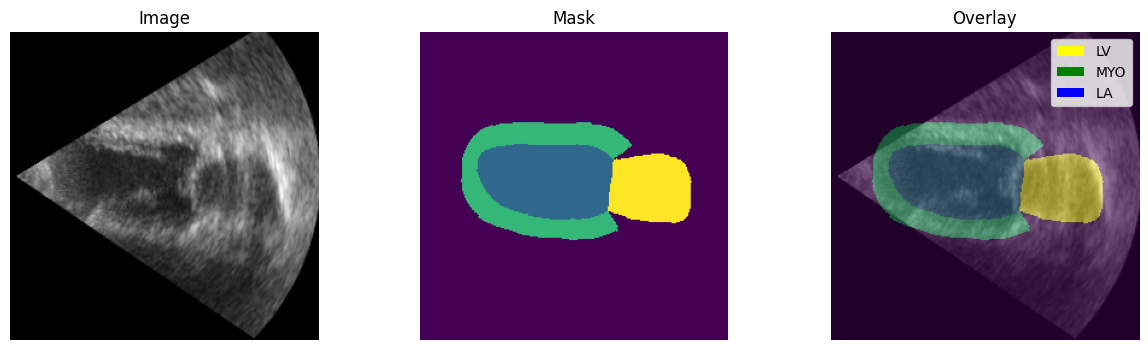

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

img, mask = train_ds[0]

img_np = img.squeeze().cpu().numpy()
mask_np = mask.cpu().numpy()

colors = [
    (0,0,0,0),        # BG transparent
    (1,0,0,0.6),      # LV yellow
    (0,1,0,0.6),      # MYO green
    (0,0,1,0.6)       # LA blue
]

legend_elements = [
    Patch(facecolor='yellow', label='LV'),
    Patch(facecolor='green', label='MYO'),
    Patch(facecolor='blue', label='LA')
]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img_np, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask_np)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img_np, cmap="gray")
plt.imshow(mask_np, alpha=0.5)
plt.legend(handles=legend_elements, loc="upper right")
plt.axis("off")

plt.show()

In [14]:
# =========================
# SAMPLERS
# WEIGHTED + BALANCED
# =========================
def get_mask_class_presence(mask_path):
    mask = np.asanyarray(nib.load(mask_path).dataobj).astype(np.int64)
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    return np.unique(mask)

def compute_weighted_sampler_weights(dataset):
    weights = []
    for _, mask_path in dataset.pairs:
        classes_present = get_mask_class_presence(mask_path)

        w = 1.0
        if 3 in classes_present:   # LA
            w += 2.0
        if 2 in classes_present:   # MYO
            w += 1.5
        if 1 in classes_present:   # LV
            w += 1.0

        weights.append(w)

    return torch.DoubleTensor(weights)

def compute_balanced_sampler_weights(dataset):
    weights = []
    for _, mask_path in dataset.pairs:
        classes_present = get_mask_class_presence(mask_path)

        if 3 in classes_present:
            w = 4.0
        elif 2 in classes_present:
            w = 3.0
        elif 1 in classes_present:
            w = 2.0
        else:
            w = 1.0

        weights.append(w)

    return torch.DoubleTensor(weights)

def make_train_loader(train_ds, sampler_choice):
    if sampler_choice == "weighted":
        sample_weights = compute_weighted_sampler_weights(train_ds)
    elif sampler_choice == "balanced":
        sample_weights = compute_balanced_sampler_weights(train_ds)
    else:
        raise ValueError("sampler_choice must be 'weighted' or 'balanced'")

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    return DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        worker_init_fn=seed_worker,
        generator=g,
    )

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
)

SAMPLER_CHOICE = "balanced"
train_loader = make_train_loader(train_ds, SAMPLER_CHOICE)

print("Training sampler:", SAMPLER_CHOICE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Training sampler: balanced
Train batches: 400
Val batches: 100


In [15]:
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Batch size:", BATCH_SIZE)

Train samples: 1600
Val samples: 400
Train batches: 400
Val batches: 100
Batch size: 4


In [16]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
)

SAMPLER_CHOICE = "balanced"   # only for preview / analysis
train_loader = make_train_loader(train_ds, SAMPLER_CHOICE)

print("Training sampler:", SAMPLER_CHOICE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Training sampler: balanced
Train batches: 400
Val batches: 100


In [17]:
# =========================
# PIXEL SHARE CHECK
# =========================
def compute_pixel_share(loader, max_batches=None):
    cnt = Counter()

    for b, (_, y) in enumerate(loader):
        y = y.numpy()
        for cls in [0, 1, 2, 3]:
            cnt[cls] += int((y == cls).sum())

        if max_batches is not None and (b + 1) >= max_batches:
            break

    total = sum(cnt.values())
    return {
        "BG": cnt[0] / total,
        "LV": cnt[1] / total,
        "MYO": cnt[2] / total,
        "LA": cnt[3] / total
    }

pixel_share = compute_pixel_share(train_loader, max_batches=20)
pd.DataFrame([pixel_share])

,BG,LV,MYO,LA
0,0.757541,0.09146,0.099007,0.051992


In [18]:
# =========================
# MODELS
# =========================
def model_unet():     # Paper 1 + Paper 5
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

def model_deeplab():  # Paper 2
    return smp.DeepLabV3(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

def model_resunet():  # Paper 4
    return smp.Unet(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

In [19]:
# =========================
# LOSSES
# NON-FOCAL = WEIGHTED CE
# FOCAL + DICE = FOR ALL FOCAL RUNS
# =========================
def soft_dice_loss(logits, targets, num_classes=NUM_CLASSES, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_oh = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    intersection = torch.sum(probs * targets_oh, dims)
    union = torch.sum(probs + targets_oh, dims)
    dice = (2 * intersection + eps) / (union + eps)

    # ignore background
    return 1 - dice[1:].mean()

class CEPlusDice(nn.Module):
    def __init__(self, ce_weight=0.5, ce_loss=None):
        super().__init__()
        self.ce_weight = ce_weight
        self.ce = ce_loss if ce_loss is not None else nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + (1 - self.ce_weight) * soft_dice_loss(logits, targets)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_map = self.alpha[targets]
            focal = alpha_map * focal

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal

class FocalPlusDice(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, focal_weight=0.5):
        super().__init__()
        self.focal = FocalLoss(alpha=alpha, gamma=gamma, reduction="mean")
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        return self.focal_weight * self.focal(logits, targets) + (1 - self.focal_weight) * soft_dice_loss(logits, targets)

class_weights = torch.tensor([0.2, 1.0, 1.0, 1.3], device=device)

ce_weighted = nn.CrossEntropyLoss(weight=class_weights)
ce_plus_dice = CEPlusDice(ce_weight=0.5, ce_loss=ce_weighted)

focal_plus_dice = FocalPlusDice(
    alpha=class_weights,
    gamma=2.0,
    focal_weight=0.5
)

print("Losses ready")
print("Class weights:", class_weights.detach().cpu().numpy())

Losses ready
Class weights: [0.2 1.  1.  1.3]


In [20]:
# =========================
# METRICS
# =========================
def dice_per_class(preds, targets, cls, eps=1e-6):
    pred_c = (preds == cls).astype(np.uint8)
    targ_c = (targets == cls).astype(np.uint8)

    inter = (pred_c * targ_c).sum()
    denom = pred_c.sum() + targ_c.sum()

    if denom == 0:
        return np.nan

    return (2.0 * inter + eps) / (denom + eps)

def evaluate_fast(model, loader):
    model.eval()

    d1, d2, d3 = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_np = y.numpy()

            for i in range(len(preds)):
                d_lv  = dice_per_class(preds[i], y_np[i], 1)
                d_myo = dice_per_class(preds[i], y_np[i], 2)
                d_la  = dice_per_class(preds[i], y_np[i], 3)

                if not np.isnan(d_lv):
                    d1.append(d_lv)
                if not np.isnan(d_myo):
                    d2.append(d_myo)
                if not np.isnan(d_la):
                    d3.append(d_la)

    fg_all = d1 + d2 + d3
    return {
        "dice_LV":  float(np.mean(d1)) if len(d1) else np.nan,
        "dice_MYO": float(np.mean(d2)) if len(d2) else np.nan,
        "dice_LA":  float(np.mean(d3)) if len(d3) else np.nan,
        "fg_dice_mean": float(np.mean(fg_all)) if len(fg_all) else np.nan
    }

In [21]:
# =========================
# OPTIONAL HD95
# =========================
try:
    !pip install -q medpy
    from medpy.metric.binary import hd95 as medpy_hd95
    HD95_AVAILABLE = True
except:
    HD95_AVAILABLE = False

def evaluate_hd95_only(model, loader):
    if not HD95_AVAILABLE:
        return {
            "hd95_LV": np.nan,
            "hd95_MYO": np.nan,
            "hd95_LA": np.nan
        }

    model.eval()
    hd_lv, hd_myo, hd_la = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_np = y.numpy()

            for i in range(len(preds)):
                for cls, bucket in [(1, hd_lv), (2, hd_myo), (3, hd_la)]:
                    pred_bin = (preds[i] == cls).astype(np.uint8)
                    true_bin = (y_np[i] == cls).astype(np.uint8)

                    if pred_bin.sum() == 0 or true_bin.sum() == 0:
                        continue

                    try:
                        bucket.append(medpy_hd95(pred_bin, true_bin))
                    except:
                        pass

    return {
        "hd95_LV":  float(np.mean(hd_lv))  if len(hd_lv)  else np.nan,
        "hd95_MYO": float(np.mean(hd_myo)) if len(hd_myo) else np.nan,
        "hd95_LA":  float(np.mean(hd_la))  if len(hd_la)  else np.nan
    }

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 46.6 MB/s eta 0:00:00


In [22]:
# =========================
# TRAINING
# =========================
train_histories = {}

def train_model_best(model, loss_fn, epochs=10, log_every=10, patience=3, lr=1e-4, run_name="run"):
    global train_loader, val_loader

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=1
    )
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_score = -1
    best_wts = None
    wait = 0
    history = []

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0

        for bi, (x, y) in enumerate(train_loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True).long()

            opt.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = loss_fn(logits, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            train_loss_sum += loss.item()

        train_loss = train_loss_sum / max(1, len(train_loader))

        model.eval()
        val_loss_sum = 0.0
        val_dices = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True).long()

                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = loss_fn(logits, y)

                val_loss_sum += loss.item()

                preds = torch.argmax(logits, dim=1).cpu().numpy()
                y_np = y.cpu().numpy()

                batch_fg = []
                for i in range(len(preds)):
                    for cls in [1, 2, 3]:
                        d = dice_per_class(preds[i], y_np[i], cls)
                        if not np.isnan(d):
                            batch_fg.append(d)

                if len(batch_fg):
                    val_dices.append(np.mean(batch_fg))

        val_loss = val_loss_sum / max(1, len(val_loader))
        val_score = float(np.mean(val_dices)) if len(val_dices) else 0.0

        scheduler.step(val_score)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_fg_dice": val_score,
            "lr": opt.param_groups[0]["lr"]
        })

        print(f"{run_name} | Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_fg_dice={val_score:.4f}")

        if val_score > best_score:
            best_score = val_score
            best_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered for {run_name}")
                break

    if best_wts is not None:
        model.load_state_dict(best_wts)

    train_histories[run_name] = pd.DataFrame(history)
    return model

In [23]:
# =========================
# RUN ONE
# NOTE: PAPER 3
# NON-FOCAL -> CE + DICE
# FOCAL     -> FOCAL + DICE
# =========================
results = {}
all_rows = []

def run_one(name, model_fn, loss_fn, sampler_choice):
    global train_loader

    print("\n" + "=" * 70)
    print("Starting:", name)
    print("=" * 70)

    train_loader = make_train_loader(train_ds, sampler_choice)
    print("Sampler:", sampler_choice)
    print("Train batches:", len(train_loader))
    print("Val batches:", len(val_loader))

    m = model_fn()

    start_time = time.time()

    m = train_model_best(
        m,
        loss_fn,
        epochs=EPOCHS,
        log_every=10,
        patience=3,
        lr=1e-4,
        run_name=name
    )

    elapsed = time.time() - start_time

    res = evaluate_fast(m, val_loader)
    res.update(evaluate_hd95_only(m, val_loader))
    results[name] = res

    weight_file = f"best_{name}.pth"
    hist_file = f"history_{name}.csv"

    torch.save(m.state_dict(), weight_file)

    hist_df = train_histories[name].copy()
    hist_df["Experiment_Name"] = name
    hist_df["Sampler"] = sampler_choice
    hist_df.to_csv(hist_file, index=False)

    row = {"Experiment_Name": name, "Sampler": sampler_choice}
    row.update(res)
    row["Time_Sec"] = elapsed
    row["Weight_File"] = weight_file
    row["History_File"] = hist_file
    all_rows.append(row)

    print("Finished:", name)
    print("Metrics:", res)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return m

In [24]:
img, mask = train_ds[0]
print("img dtype:", img.dtype, "shape:", img.shape)
print("mask dtype:", mask.dtype, "shape:", mask.shape)
print("unique mask labels:", torch.unique(mask))

img dtype: torch.float32 shape: torch.Size([1, 256, 256])
mask dtype: torch.int64 shape: torch.Size([256, 256])
unique mask labels: tensor([0, 1, 2, 3])


In [25]:
test_model = run_one("debug_test", model_unet, ce_weighted, "balanced")


Starting: debug_test
Sampler: balanced
Train batches: 400
Val batches: 100


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

debug_test | Epoch 1/10 | train_loss=0.5333 | val_loss=0.5767 | val_fg_dice=0.6485
debug_test | Epoch 2/10 | train_loss=0.2455 | val_loss=0.2073 | val_fg_dice=0.8448
debug_test | Epoch 3/10 | train_loss=0.2073 | val_loss=0.4241 | val_fg_dice=0.6868
debug_test | Epoch 4/10 | train_loss=0.1792 | val_loss=0.1869 | val_fg_dice=0.8563
debug_test | Epoch 5/10 | train_loss=0.1746 | val_loss=0.2193 | val_fg_dice=0.8249
debug_test | Epoch 6/10 | train_loss=0.1693 | val_loss=0.1608 | val_fg_dice=0.8490
debug_test | Epoch 7/10 | train_loss=0.1554 | val_loss=0.1601 | val_fg_dice=0.8510
Early stopping triggered for debug_test
Finished: debug_test
Metrics: {'dice_LV': 0.9017873161167067, 'dice_MYO': 0.8264080423809445, 'dice_LA': 0.8436311763715076, 'fg_dice_mean': 0.8572755116230528, 'hd95_LV': 8.949541160602493, 'hd95_MYO': 9.577367629551047, 'hd95_LA': 11.498660096762116}


In [26]:
# =========================
# RUN ALL 20 EXPERIMENTS
# 5 MODELS × 2 SAMPLERS × 2 LOSS TYPES
# =========================

# ---------- WEIGHTED + NON-FOCAL ----------
m1_wn = run_one("Paper1_UNet_weighted_non_focal", model_unet, ce_weighted, "weighted")
m2_wn = run_one("Paper2_DeepLabV3_weighted_non_focal", model_deeplab, ce_weighted, "weighted")
m3_wn = run_one("Paper3_UNet_CE+Dice_weighted_non_focal", model_unet, ce_plus_dice, "weighted")
m4_wn = run_one("Paper4_ResUNet_weighted_non_focal", model_resunet, ce_weighted, "weighted")
m5_wn = run_one("Paper5_UNet_Baseline_weighted_non_focal", model_unet, ce_weighted, "weighted")

# ---------- WEIGHTED + FOCAL + DICE ----------
m1_wf = run_one("Paper1_UNet_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")
m2_wf = run_one("Paper2_DeepLabV3_weighted_focal_dice", model_deeplab, focal_plus_dice, "weighted")
m3_wf = run_one("Paper3_UNet_CE+Dice_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")
m4_wf = run_one("Paper4_ResUNet_weighted_focal_dice", model_resunet, focal_plus_dice, "weighted")
m5_wf = run_one("Paper5_UNet_Baseline_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")

# ---------- BALANCED + NON-FOCAL ----------
m1_bn = run_one("Paper1_UNet_balanced_non_focal", model_unet, ce_weighted, "balanced")
m2_bn = run_one("Paper2_DeepLabV3_balanced_non_focal", model_deeplab, ce_weighted, "balanced")
m3_bn = run_one("Paper3_UNet_CE+Dice_balanced_non_focal", model_unet, ce_plus_dice, "balanced")
m4_bn = run_one("Paper4_ResUNet_balanced_non_focal", model_resunet, ce_weighted, "balanced")
m5_bn = run_one("Paper5_UNet_Baseline_balanced_non_focal", model_unet, ce_weighted, "balanced")

# ---------- BALANCED + FOCAL + DICE ----------
m1_bf = run_one("Paper1_UNet_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")
m2_bf = run_one("Paper2_DeepLabV3_balanced_focal_dice", model_deeplab, focal_plus_dice, "balanced")
m3_bf = run_one("Paper3_UNet_CE+Dice_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")
m4_bf = run_one("Paper4_ResUNet_balanced_focal_dice", model_resunet, focal_plus_dice, "balanced")
m5_bf = run_one("Paper5_UNet_Baseline_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")


Starting: Paper1_UNet_weighted_non_focal
Sampler: weighted
Train batches: 400
Val batches: 100
Paper1_UNet_weighted_non_focal | Epoch 1/10 | train_loss=0.6281 | val_loss=0.3444 | val_fg_dice=0.7433
Paper1_UNet_weighted_non_focal | Epoch 2/10 | train_loss=0.2502 | val_loss=0.3743 | val_fg_dice=0.7551
Paper1_UNet_weighted_non_focal | Epoch 3/10 | train_loss=0.2079 | val_loss=0.1876 | val_fg_dice=0.8514
Paper1_UNet_weighted_non_focal | Epoch 4/10 | train_loss=0.1892 | val_loss=0.8448 | val_fg_dice=0.5933
Paper1_UNet_weighted_non_focal | Epoch 5/10 | train_loss=0.1778 | val_loss=0.1660 | val_fg_dice=0.8658
Paper1_UNet_weighted_non_focal | Epoch 6/10 | train_loss=0.1683 | val_loss=0.1942 | val_fg_dice=0.8396
Paper1_UNet_weighted_non_focal | Epoch 7/10 | train_loss=0.1599 | val_loss=0.1811 | val_fg_dice=0.8412
Paper1_UNet_weighted_non_focal | Epoch 8/10 | train_loss=0.1447 | val_loss=0.1386 | val_fg_dice=0.8753
Paper1_UNet_weighted_non_focal | Epoch 9/10 | train_loss=0.1454 | val_loss=0.142

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Paper4_ResUNet_weighted_non_focal | Epoch 1/10 | train_loss=0.4776 | val_loss=0.2483 | val_fg_dice=0.8154
Paper4_ResUNet_weighted_non_focal | Epoch 2/10 | train_loss=0.2270 | val_loss=0.2099 | val_fg_dice=0.8284
Paper4_ResUNet_weighted_non_focal | Epoch 3/10 | train_loss=0.2110 | val_loss=0.1838 | val_fg_dice=0.8422
Paper4_ResUNet_weighted_non_focal | Epoch 4/10 | train_loss=0.1782 | val_loss=0.1735 | val_fg_dice=0.8656
Paper4_ResUNet_weighted_non_focal | Epoch 5/10 | train_loss=0.1815 | val_loss=0.1930 | val_fg_dice=0.8562
Paper4_ResUNet_weighted_non_focal | Epoch 6/10 | train_loss=0.1699 | val_loss=0.1774 | val_fg_dice=0.8627
Paper4_ResUNet_weighted_non_focal | Epoch 7/10 | train_loss=0.1488 | val_loss=0.1505 | val_fg_dice=0.8746
Paper4_ResUNet_weighted_non_focal | Epoch 8/10 | train_loss=0.1457 | val_loss=0.1459 | val_fg_dice=0.8783
Paper4_ResUNet_weighted_non_focal | Epoch 9/10 | train_loss=0.1433 | val_loss=0.1500 | val_fg_dice=0.8674
Paper4_ResUNet_weighted_non_focal | Epoch 10/1

In [27]:
results_df = pd.DataFrame(all_rows)
print("Number of experiments:", len(results_df))
results_df.head()

Number of experiments: 21


,Experiment_Name,Sampler,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,Time_Sec,Weight_File,History_File
0,debug_test,balanced,0.901787,0.826408,0.843631,0.857276,8.949541,9.577368,11.498660,105.511180,best_debug_test.pth,history_debug_test.csv
1,Paper1_UNet_weighted_non_focal,weighted,0.930519,0.857189,0.857049,0.881586,6.536484,7.343306,10.897560,151.415311,best_Paper1_UNet_weighted_non_focal.pth,history_Paper1_UNet_weighted_non_focal.csv
2,Paper2_DeepLabV3_weighted_non_focal,weighted,0.927663,0.846986,0.871160,0.881936,6.489712,8.050578,9.495667,145.171983,best_Paper2_DeepLabV3_weighted_non_focal.pth,history_Paper2_DeepLabV3_weighted_non_focal.csv
3,Paper3_UNet_CE+Dice_weighted_non_focal,weighted,0.924017,0.852896,0.887615,0.888176,6.720479,7.458303,8.949984,123.075261,best_Paper3_UNet_CE+Dice_weighted_non_focal.pth,history_Paper3_UNet_CE+Dice_weighted_non_focal...
4,Paper4_ResUNet_weighted_non_focal,weighted,0.928921,0.834268,0.875188,0.879459,6.322987,8.129934,8.941783,185.309736,best_Paper4_ResUNet_weighted_non_focal.pth,history_Paper4_ResUNet_weighted_non_focal.csv


In [28]:
def parse_experiment_name(name):
    parts = name.split("_")

    sampler = "weighted" if "weighted" in parts else "balanced"

    if "non" in parts and "focal" in parts:
        loss_type = "non_focal"
    elif "focal" in parts and "dice" in parts:
        loss_type = "focal_dice"
    else:
        loss_type = "unknown"

    if name.startswith("Paper1"):
        model = "Paper1_UNet"
    elif name.startswith("Paper2"):
        model = "Paper2_DeepLabV3"
    elif name.startswith("Paper3"):
        model = "Paper3_UNet_CE+Dice"
    elif name.startswith("Paper4"):
        model = "Paper4_ResUNet"
    elif name.startswith("Paper5"):
        model = "Paper5_UNet_Baseline"
    else:
        model = "unknown"

    return pd.Series([model, sampler, loss_type])

results_df[["Model", "Sampler", "Loss_Type"]] = results_df["Experiment_Name"].apply(parse_experiment_name)
results_df.head()

,Experiment_Name,Sampler,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,Time_Sec,Weight_File,History_File,Model,Loss_Type
0,debug_test,balanced,0.901787,0.826408,0.843631,0.857276,8.949541,9.577368,11.498660,105.511180,best_debug_test.pth,history_debug_test.csv,unknown,unknown
1,Paper1_UNet_weighted_non_focal,weighted,0.930519,0.857189,0.857049,0.881586,6.536484,7.343306,10.897560,151.415311,best_Paper1_UNet_weighted_non_focal.pth,history_Paper1_UNet_weighted_non_focal.csv,Paper1_UNet,non_focal
2,Paper2_DeepLabV3_weighted_non_focal,weighted,0.927663,0.846986,0.871160,0.881936,6.489712,8.050578,9.495667,145.171983,best_Paper2_DeepLabV3_weighted_non_focal.pth,history_Paper2_DeepLabV3_weighted_non_focal.csv,Paper2_DeepLabV3,non_focal
3,Paper3_UNet_CE+Dice_weighted_non_focal,weighted,0.924017,0.852896,0.887615,0.888176,6.720479,7.458303,8.949984,123.075261,best_Paper3_UNet_CE+Dice_weighted_non_focal.pth,history_Paper3_UNet_CE+Dice_weighted_non_focal...,Paper3_UNet_CE+Dice,non_focal
4,Paper4_ResUNet_weighted_non_focal,weighted,0.928921,0.834268,0.875188,0.879459,6.322987,8.129934,8.941783,185.309736,best_Paper4_ResUNet_weighted_non_focal.pth,history_Paper4_ResUNet_weighted_non_focal.csv,Paper4_ResUNet,non_focal


In [29]:
report_df = results_df[[
    "Model",
    "Sampler",
    "Loss_Type",
    "dice_LV",
    "dice_MYO",
    "dice_LA",
    "fg_dice_mean",
    "hd95_LV",
    "hd95_MYO",
    "hd95_LA",
    "Time_Sec"
]].copy()

report_df = report_df.sort_values("fg_dice_mean", ascending=False).reset_index(drop=True)
report_df

,Model,Sampler,Loss_Type,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,Time_Sec
0,Paper3_UNet_CE+Dice,balanced,focal_dice,0.930930,0.865658,0.895867,0.897485,6.313177,6.875388,7.479426,161.090884
1,Paper5_UNet_Baseline,weighted,focal_dice,0.932761,0.867231,0.890291,0.896761,6.089150,6.592521,7.788974,158.698547
2,Paper4_ResUNet,balanced,focal_dice,0.929004,0.859789,0.897044,0.895279,6.328210,7.032828,7.440876,192.841584
3,Paper1_UNet,weighted,focal_dice,0.930214,0.863960,0.889265,0.894480,6.383411,6.991115,7.879893,158.544204
4,Paper5_UNet_Baseline,balanced,focal_dice,0.925768,0.861936,0.893806,0.893836,6.542727,6.807000,7.980439,161.079365
5,Paper1_UNet,balanced,focal_dice,0.929281,0.865017,0.886494,0.893598,6.616369,7.084342,8.563819,161.612165
6,Paper4_ResUNet,weighted,focal_dice,0.928025,0.857829,0.894612,0.893489,6.392648,7.159692,7.686900,193.659680
7,Paper3_UNet_CE+Dice,balanced,non_focal,0.931814,0.861698,0.886077,0.893197,6.132912,7.116511,8.180709,157.198762
8,Paper3_UNet_CE+Dice,weighted,focal_dice,0.928487,0.853403,0.892078,0.891323,6.431248,7.652621,7.867415,160.015816
9,Paper3_UNet_CE+Dice,weighted,non_focal,0.924017,0.852896,0.887615,0.888176,6.720479,7.458303,8.949984,123.075261


In [30]:
report_df.to_csv("clean_report_results_table.csv", index=False)
print("Saved: clean_report_results_table.csv")

Saved: clean_report_results_table.csv


In [31]:
comparison_table = results_df.pivot_table(
    index="Model",
    columns=["Sampler", "Loss_Type"],
    values="fg_dice_mean"
)

comparison_table

Sampler                balanced                       weighted          
Loss_Type            focal_dice non_focal   unknown focal_dice non_focal
Model                                                                   
Paper1_UNet            0.893598  0.882615       NaN   0.894480  0.881586
Paper2_DeepLabV3       0.884366  0.884585       NaN   0.885990  0.881936
Paper3_UNet_CE+Dice    0.897485  0.893197       NaN   0.891323  0.888176
Paper4_ResUNet         0.895279  0.880419       NaN   0.893489  0.879459
Paper5_UNet_Baseline   0.893836  0.865275       NaN   0.896761  0.874117
unknown                     NaN       NaN  0.857276        NaN       NaN

In [32]:
comparison_table.to_csv("compact_model_comparison_table.csv")
print("Saved: compact_model_comparison_table.csv")

Saved: compact_model_comparison_table.csv


In [33]:
leaderboard_df = results_df[[
    "Experiment_Name",
    "Model",
    "Sampler",
    "Loss_Type",
    "fg_dice_mean",
    "dice_LV",
    "dice_MYO",
    "dice_LA",
    "Time_Sec"
]].sort_values("fg_dice_mean", ascending=False).reset_index(drop=True)

leaderboard_df

,Experiment_Name,Model,Sampler,Loss_Type,fg_dice_mean,dice_LV,dice_MYO,dice_LA,Time_Sec
0,Paper3_UNet_CE+Dice_balanced_focal_dice,Paper3_UNet_CE+Dice,balanced,focal_dice,0.897485,0.930930,0.865658,0.895867,161.090884
1,Paper5_UNet_Baseline_weighted_focal_dice,Paper5_UNet_Baseline,weighted,focal_dice,0.896761,0.932761,0.867231,0.890291,158.698547
2,Paper4_ResUNet_balanced_focal_dice,Paper4_ResUNet,balanced,focal_dice,0.895279,0.929004,0.859789,0.897044,192.841584
3,Paper1_UNet_weighted_focal_dice,Paper1_UNet,weighted,focal_dice,0.894480,0.930214,0.863960,0.889265,158.544204
4,Paper5_UNet_Baseline_balanced_focal_dice,Paper5_UNet_Baseline,balanced,focal_dice,0.893836,0.925768,0.861936,0.893806,161.079365
5,Paper1_UNet_balanced_focal_dice,Paper1_UNet,balanced,focal_dice,0.893598,0.929281,0.865017,0.886494,161.612165
6,Paper4_ResUNet_weighted_focal_dice,Paper4_ResUNet,weighted,focal_dice,0.893489,0.928025,0.857829,0.894612,193.659680
7,Paper3_UNet_CE+Dice_balanced_non_focal,Paper3_UNet_CE+Dice,balanced,non_focal,0.893197,0.931814,0.861698,0.886077,157.198762
8,Paper3_UNet_CE+Dice_weighted_focal_dice,Paper3_UNet_CE+Dice,weighted,focal_dice,0.891323,0.928487,0.853403,0.892078,160.015816
9,Paper3_UNet_CE+Dice_weighted_non_focal,Paper3_UNet_CE+Dice,weighted,non_focal,0.888176,0.924017,0.852896,0.887615,123.075261


In [34]:
leaderboard_df.to_csv("leaderboard_all_20_runs.csv", index=False)
print("Saved: leaderboard_all_10Epochs_runs.csv")

Saved: leaderboard_all_10Epochs_runs.csv


In [35]:

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch

# ---- Class names ----
CLASS_NAMES = {
    0: "Background",
    1: "LV",
    2: "MYO",
    3: "LA"
}

# ---- Overlay colors ----
CLASS_COLORS = {
    0: (0, 0, 0, 0.0),
    1: (1, 1, 0, 0.55),   # yellow
    2: (0, 1, 0, 0.55),   # green
    3: (0, 0, 1, 0.55)    # blue
}

legend_elements = [
    Patch(facecolor='yellow', label='LV'),
    Patch(facecolor='green', label='MYO'),
    Patch(facecolor='blue', label='LA')
]

def denormalize_image(img_tensor):
    img = img_tensor.squeeze().cpu().numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    return img

def mask_to_rgba(mask):
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    for cls, color in CLASS_COLORS.items():
        rgba[mask == cls] = color
    return rgba

def dice_one_class(pred, target, cls, eps=1e-6):
    pred_c = (pred == cls).astype(np.uint8)
    target_c = (target == cls).astype(np.uint8)
    inter = (pred_c * target_c).sum()
    denom = pred_c.sum() + target_c.sum()
    if denom == 0:
        return np.nan
    return (2.0 * inter + eps) / (denom + eps)

def get_prediction(model, dataset, idx, device):
    model.eval()

    img, true_mask = dataset[idx]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        if isinstance(logits, (tuple, list)):
            logits = logits[0]
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    img_np = denormalize_image(img)
    true_np = true_mask.cpu().numpy() if torch.is_tensor(true_mask) else np.array(true_mask)

    return img_np, true_np, pred_mask

def show_prediction(model, dataset, idx=None, device="cpu", figsize=(18, 8)):
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    img_np, true_np, pred_np = get_prediction(model, dataset, idx, device)

    dice_lv = dice_one_class(pred_np, true_np, 1)
    dice_myo = dice_one_class(pred_np, true_np, 2)
    dice_la = dice_one_class(pred_np, true_np, 3)

    gt_overlay = mask_to_rgba(true_np)
    pred_overlay = mask_to_rgba(pred_np)

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    axes[0, 0].imshow(img_np, cmap="gray")
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(true_np, cmap="viridis")
    axes[0, 1].set_title("Ground Truth")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(pred_np, cmap="viridis")
    axes[0, 2].set_title("Prediction")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(img_np, cmap="gray")
    axes[1, 0].imshow(gt_overlay)
    axes[1, 0].set_title("GT Overlay")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(img_np, cmap="gray")
    axes[1, 1].imshow(pred_overlay)
    axes[1, 1].set_title("Prediction Overlay")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(true_np, cmap="gray", alpha=0.5)
    axes[1, 2].imshow(pred_np, cmap="jet", alpha=0.5)
    axes[1, 2].set_title(
        f"Dice Scores\nLV={dice_lv:.3f}, MYO={dice_myo:.3f}, LA={dice_la:.3f}"
    )
    axes[1, 2].axis("off")

    fig.legend(handles=legend_elements, loc="lower center", ncol=3)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

def save_prediction_figure(model, dataset, idx, save_dir="visual_results", device="cpu"):
    os.makedirs(save_dir, exist_ok=True)

    img_np, true_np, pred_np = get_prediction(model, dataset, idx, device)

    pred_overlay = mask_to_rgba(pred_np)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_np, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(true_np, cmap="viridis")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred_np, cmap="viridis")
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    axes[3].imshow(img_np, cmap="gray")
    axes[3].imshow(pred_overlay)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"sample_{idx}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {save_path}")

def save_random_examples(model, dataset, n=5, save_dir="visual_results", device="cpu"):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    for idx in indices:
        save_prediction_figure(model, dataset, idx, save_dir, device)

Best Model: Paper3_UNet_CE+Dice_balanced_focal_dice
Best Dice Score: 0.8975

Showing visual results...



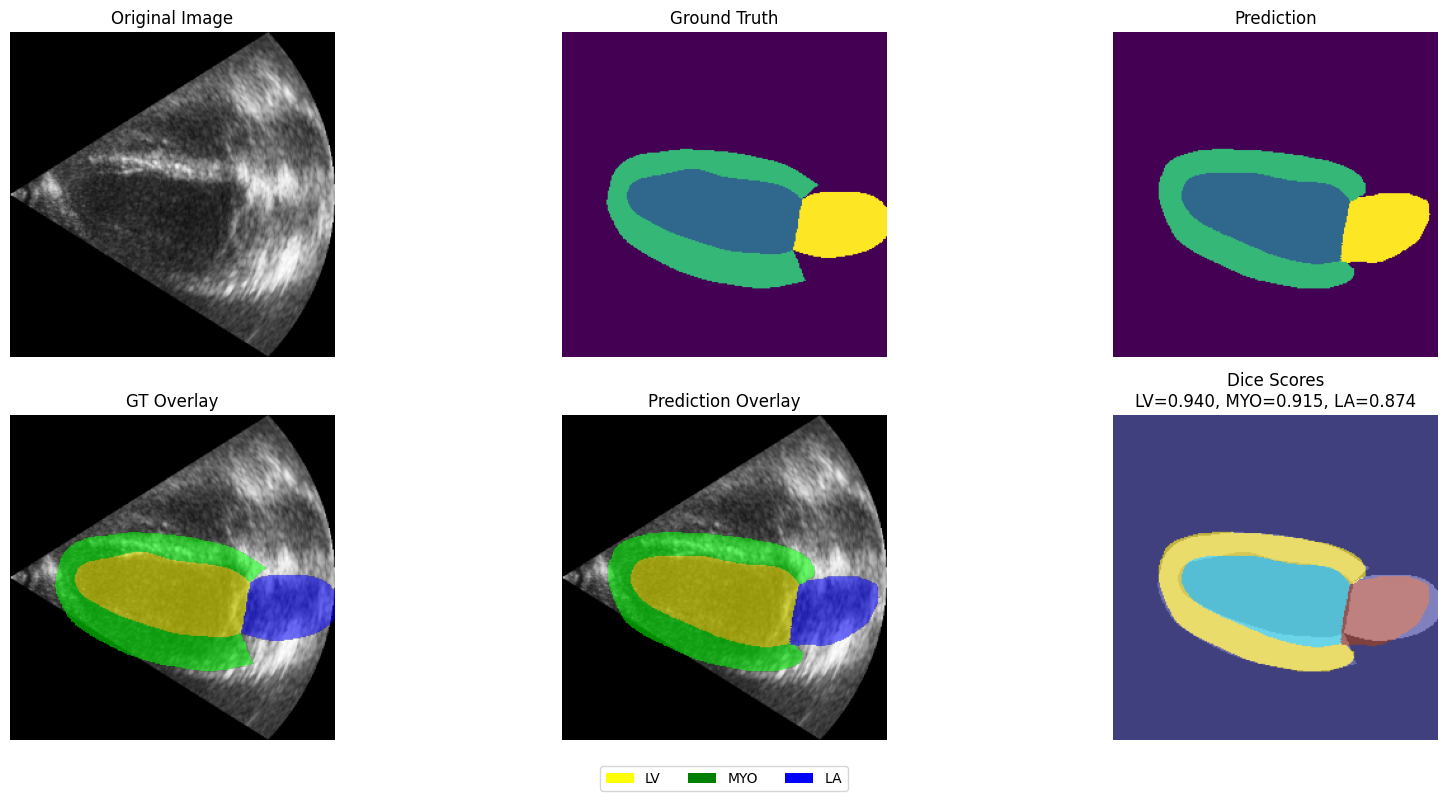

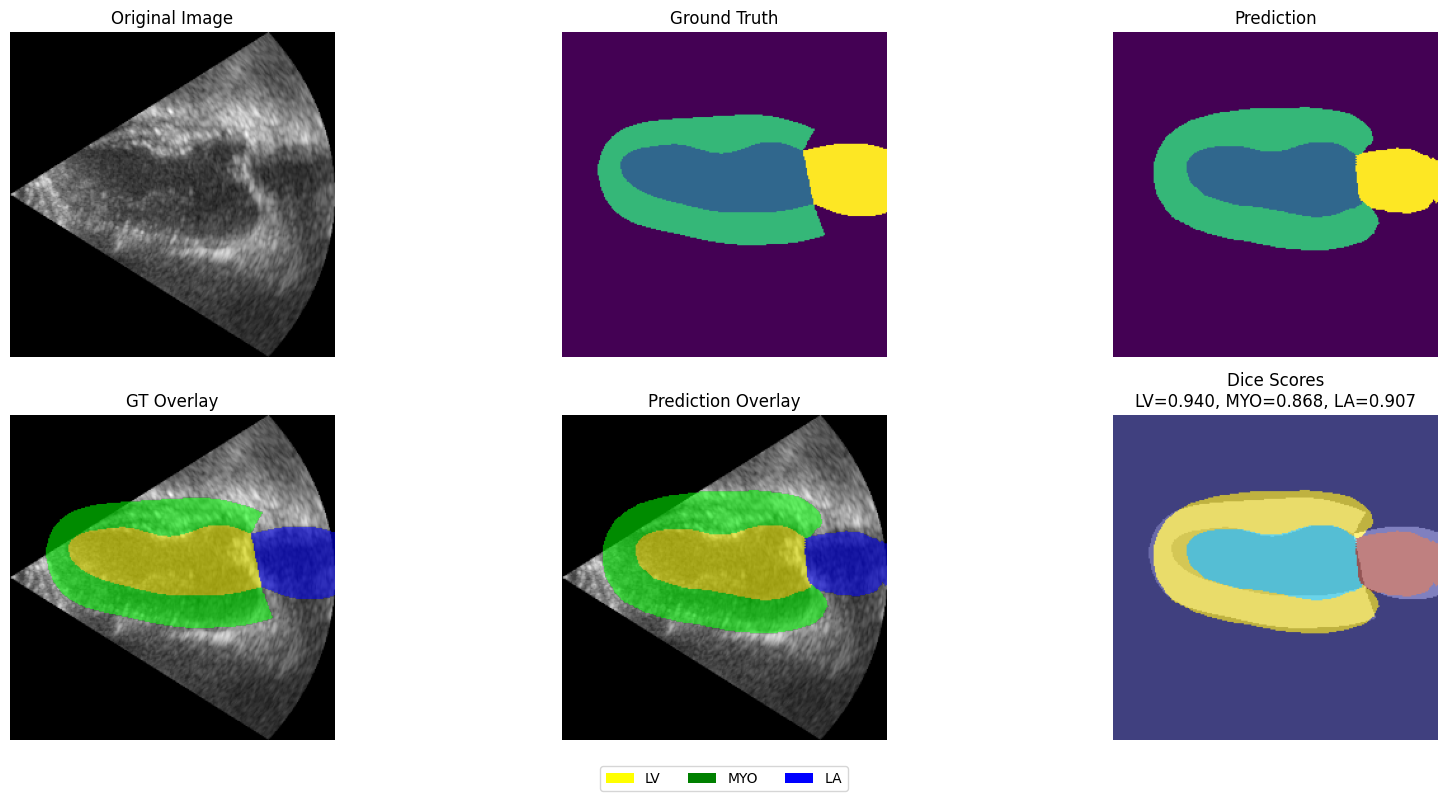

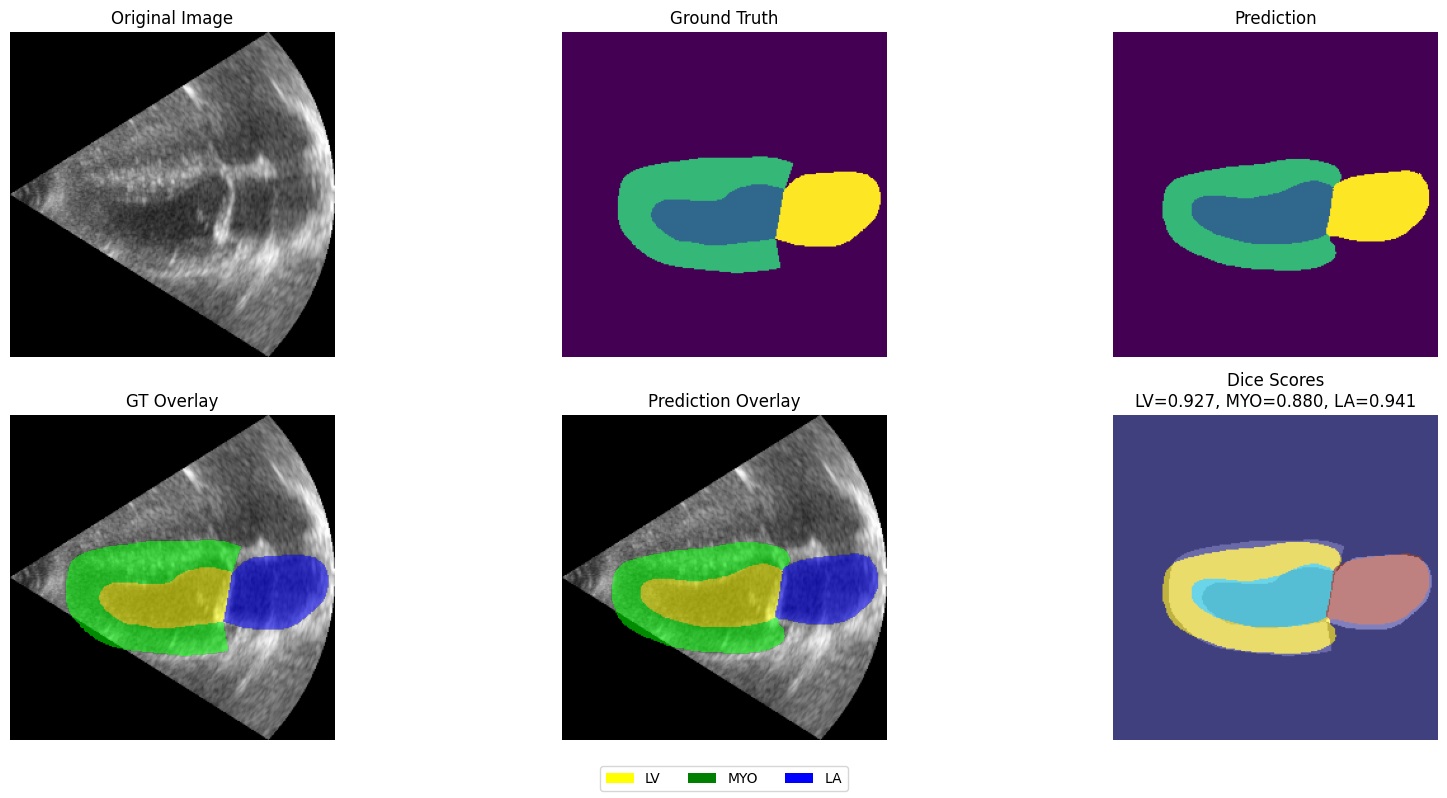


Saving images for report...

Saved: best_model_results/sample_379.png
Saved: best_model_results/sample_140.png
Saved: best_model_results/sample_125.png
Saved: best_model_results/sample_114.png
Saved: best_model_results/sample_71.png


In [36]:
# ============================================================
# AUTO SELECT BEST MODEL + VISUALISE
# ============================================================

# Sort leaderboard
best_row = leaderboard_df.sort_values(by="fg_dice_mean", ascending=False).iloc[0]

best_name = best_row["Experiment_Name"]
best_score = best_row["fg_dice_mean"]

print("Best Model:", best_name)
print("Best Dice Score:", round(best_score, 4))


# Map experiment names to models (from Cell 25)
model_dict = {
    "Paper1_UNet_weighted_non_focal": m1_wn,
    "Paper2_DeepLabV3_weighted_non_focal": m2_wn,
    "Paper3_UNet_CE+Dice_weighted_non_focal": m3_wn,
    "Paper4_ResUNet_weighted_non_focal": m4_wn,
    "Paper5_UNet_Baseline_weighted_non_focal": m5_wn,

    "Paper1_UNet_weighted_focal_dice": m1_wf,
    "Paper2_DeepLabV3_weighted_focal_dice": m2_wf,
    "Paper3_UNet_CE+Dice_weighted_focal_dice": m3_wf,
    "Paper4_ResUNet_weighted_focal_dice": m4_wf,
    "Paper5_UNet_Baseline_weighted_focal_dice": m5_wf,

    "Paper1_UNet_balanced_non_focal": m1_bn,
    "Paper2_DeepLabV3_balanced_non_focal": m2_bn,
    "Paper3_UNet_CE+Dice_balanced_non_focal": m3_bn,
    "Paper4_ResUNet_balanced_non_focal": m4_bn,
    "Paper5_UNet_Baseline_balanced_non_focal": m5_bn,

    "Paper1_UNet_balanced_focal_dice": m1_bf,
    "Paper2_DeepLabV3_balanced_focal_dice": m2_bf,
    "Paper3_UNet_CE+Dice_balanced_focal_dice": m3_bf,
    "Paper4_ResUNet_balanced_focal_dice": m4_bf,
    "Paper5_UNet_Baseline_balanced_focal_dice": m5_bf,
}

# Get best trained model
best_model = model_dict[best_name]


# ---------------------------
# SHOW RESULTS
# ---------------------------
print("\nShowing visual results...\n")

for _ in range(3):
    show_prediction(best_model, val_ds, device=device)


# ---------------------------
# SAVE IMAGES FOR REPORT
# ---------------------------
print("\nSaving images for report...\n")

save_random_examples(
    best_model,
    val_ds,
    n=5,
    save_dir="best_model_results",
    device=device
)